# Methods for reduction of dimensions by similar ratios (final version for this folder)

## Summary
This code is a principled method for reducing compounds into pairs/combinations based on a custom distance: How variable the ratio between two compounds is across samples. (For Yarrowia ONLY)

## workflow
- read in raw data of g/L concentrations for various compounds 
- remove unnecessary compounds and separate by element and vitamin
- cluster by std and maxmin to identify similarly consistent ratios across experiments.
- arbitrarily join clusters to combine compounds (allowing for reduced dimension ins Bayesian Optimisation)
- ***script to determine the 'alpha' parameter used to hold ratios constant, allowing for a BO model to learn the 1 dimension, which can include multiple compounds***

Some personal notes.

made it so std and minmax range are calculated after replacing 0 with NaN

In [2]:
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import numpy as np
import itertools

from scipy.spatial.distance import squareform
from scipy.cluster.hierarchy import linkage, dendrogram

df = pd.read_csv("data/raw/Media-Matrix-Combined-v4-moles-per-litre-annotate.csv")

# run this to remove these compounds from analysis
# filter rows that were considered not important
compounds_to_remove = [
    'Dipotassium phosphate', 'Disodium edta dihydrate', 'EDTA', 'Monopotassium phosphate',
    'Phosphoric acid', 'Potassium hydroxide', 'Sodium citrate dihydrate', 'Sodium phosphate',
    'Sulphuric acid', 'Uracil'
]
df = df[~df['Compound'].isin(compounds_to_remove)].copy()

# remove pubchemid
df.drop(df.columns[1], axis=1, inplace=True)

# separate numeric columns for transformation
num_df = df.select_dtypes(include='number')
labels = df[['Compound', 'Annotate']]

yar_df = df.filter(like='_YAR')
#cer_df = df_log.filter(like='_CER')
#pic_df = df_log.filter(like='_PIC')

yar_df_labeled = pd.concat([labels, yar_df], axis=1)

# Define which columns are sample measurements (everything except metadata)
sample_cols = yar_df_labeled.columns.difference(['Compound', 'Annotate'])

# Filter to keep rows where at least one sample value ≠ 0   # this bit was changed for the linear version of this process pipeline
yar_df_labeled = yar_df_labeled[
    yar_df_labeled['Annotate'].isin(['Vitamin', 'Element']) &
    ~(yar_df_labeled[sample_cols] == 0).all(axis=1)
].copy()

# let's remove redundant elements for calcium iron, manganese, sodium chloride and zinc chloride
yar_df_labeled = yar_df_labeled.drop(index=[9, 16, 29, 35, 46, 59])

yar_df_element = yar_df_labeled[yar_df_labeled['Annotate'] == 'Element'].copy()
yar_df_vitamin = yar_df_labeled[yar_df_labeled['Annotate'] == 'Vitamin'].copy()

In [3]:
# confirm these are properly in linear scale and not being log10 transformed as previous methods
print(yar_df_element)
print(yar_df_vitamin)


                             Compound Annotate     1_YAR        2a_YAR  \
7          Calcium chloride dihydrate  Element  0.000000  3.061016e-05   
11   Cobalt (II) chloride hexahydrate  Element  0.000011  2.310536e-06   
12  Copper (II) sulphate pentahydrate  Element  0.000188  1.879581e-06   
24         Iron sulphate heptahydrate  Element  0.001317  1.974854e-05   
28    Magnesium sulphate heptahydrate  Element  0.017031  4.153859e-03   
30    Manganese chloride tetrahydrate  Element  0.000000  4.244568e-06   
41                   Potassium iodide  Element  0.000000  6.023995e-07   
49         Sodium molybdate dihydrate  Element  0.000002  1.942408e-06   
60         Zinc sulphate heptahydrate  Element  0.000000  2.788104e-05   

          2b_YAR        2c_YAR        2d_YAR        3a_YAR    3b_YAR  \
7   3.061016e-05  3.061016e-05  3.061016e-05  6.802260e-04  0.000000   
11  2.310536e-06  2.310536e-06  2.310536e-06  0.000000e+00  0.000000   
12  1.879581e-06  1.879581e-06  1.879581e-0

Element hierarchial tree

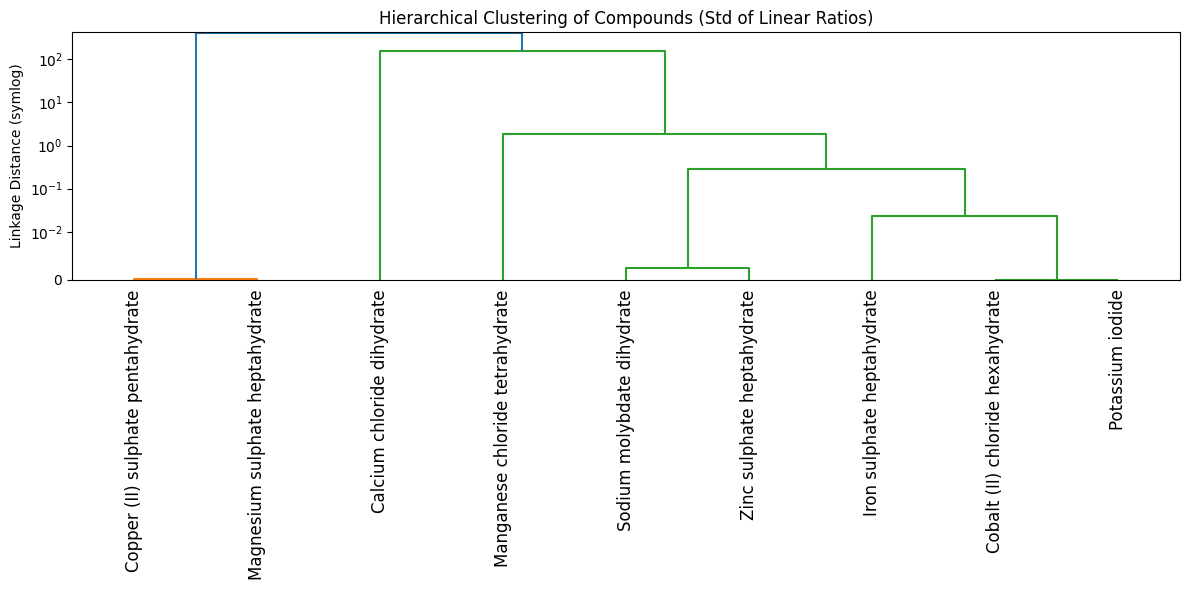

In [30]:
df_e = yar_df_element.copy()
sample_cols = df_e.columns.difference(['Compound', 'Annotate'])

ratios = []


# all unique compound pairs
compound_pairs = list(itertools.combinations(df_e['Compound'], 2))

# map for quick lookup
compound_map = df_e.set_index('Compound')[sample_cols]

# loop through pairs
for c1, c2 in compound_pairs:
    vals1 = compound_map.loc[c1]
    vals2 = compound_map.loc[c2]

    # per-column mask
    valid_mask = (vals1>0) & (vals2 >0)
    ratio = vals1/vals2 #

    #only keeps valid entries
    ratio_filtered = ratio.where(valid_mask)

    # store as a row with all per-column ratios
    row = {
        'Compound_1': c1,
        'Compound_2': c2,
        **ratio_filtered.to_dict()
    }
    ratios.append(row)

# create a dataframe
ratio_df_e = pd.DataFrame(ratios)

ratio_df_e_reduced = ratio_df_e.drop(columns = ['1_YAR', '2b_YAR', '2c_YAR', '2d_YAR', '3b_YAR', '3c_YAR']) 
# to remove 2b to 2d Yar (which are the same as 2a) and 3b(which was all nans) 3c was dropped as it was focused on protein yiedl rather than hcd/growth
# I've also removed 1_YAR as it is out of whack compared to others

# Step 1: Compute SD per row
sample_cols = ratio_df_e_reduced.columns.difference(['Compound_1', 'Compound_2'])
ratio_df_e_reduced['Std_Ratio'] = ratio_df_e_reduced[sample_cols].replace(0, np.nan).std(axis=1, skipna=True)

# Step 2: Create list of all unique compounds
compounds = pd.unique(ratio_df_e_reduced[['Compound_1', 'Compound_2']].values.ravel())

# Step 3: Initialize empty distance matrix
distance_matrix = pd.DataFrame(np.nan, index=compounds, columns=compounds)

# Step 4: Fill matrix with std values (symmetric)
for _, row in ratio_df_e_reduced.iterrows():
    c1, c2, std = row['Compound_1'], row['Compound_2'], row['Std_Ratio']
    distance_matrix.loc[c1, c2] = std
    distance_matrix.loc[c2, c1] = std

# Step 5: Set diagonal to 0
np.fill_diagonal(distance_matrix.values, 0)

# Step 6: Check for missing values
if distance_matrix.isnull().any().any():
    raise ValueError("Distance matrix contains NaNs — some compound pairs are missing.")

# Step 7: Run hierarchical clustering
condensed_dist = squareform(distance_matrix.values)
Z = linkage(condensed_dist, method='average')

# Step 8: Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=distance_matrix.index.tolist(), leaf_rotation=90)#, color_threshold=100)
plt.yscale('symlog', linthresh=.01)
plt.ylabel("Linkage Distance (symlog)")
plt.title("Hierarchical Clustering of Compounds (Std of Linear Ratios)")
plt.tight_layout()
plt.show()


In [31]:
# Get compound names
compounds = list(distance_matrix.index)

# Number of original observations
n = len(compounds)

# This will store merge history
merge_history = []

# Track cluster membership (compound names or merged groups)
clusters = {i: [compounds[i]] for i in range(n)}

# Loop over linkage matrix Z
for step, (idx1, idx2, dist, sample_count) in enumerate(Z):
    idx1, idx2 = int(idx1), int(idx2)
    
    # Get the clusters being merged
    members1 = clusters[idx1]
    members2 = clusters[idx2]

    # Merge the two clusters
    new_cluster = members1 + members2
    clusters[n + step] = new_cluster

    # Save merge info
    merge_history.append({
        'Step': step + 1,
        'Cluster_ID': n + step,
        'Merged_Cluster_1': members1,
        'Merged_Cluster_2': members2,
        'Linkage_Distance': dist,
        'Num_Compounds': len(new_cluster),
    })

# Convert to dataframe for easier viewing
merge_df = pd.DataFrame(merge_history)

# Display the merge table sorted by step (or by distance, if you prefer)
merge_df_sorted = merge_df.sort_values('Linkage_Distance', ascending=True)

# Print the table or write to CSV
print(merge_df_sorted.to_string(index=False))
# merge_df_sorted.to_csv("compound_merge_steps.csv", index=False)


 Step  Cluster_ID                                                     Merged_Cluster_1                                                                                                                                                                                      Merged_Cluster_2  Linkage_Distance  Num_Compounds
    1           9                                   [Cobalt (II) chloride hexahydrate]                                                                                                                                                                                    [Potassium iodide]          0.000000              2
    2          10                                  [Copper (II) sulphate pentahydrate]                                                                                                                                                                     [Magnesium sulphate heptahydrate]          0.000198              2
    3          11                             

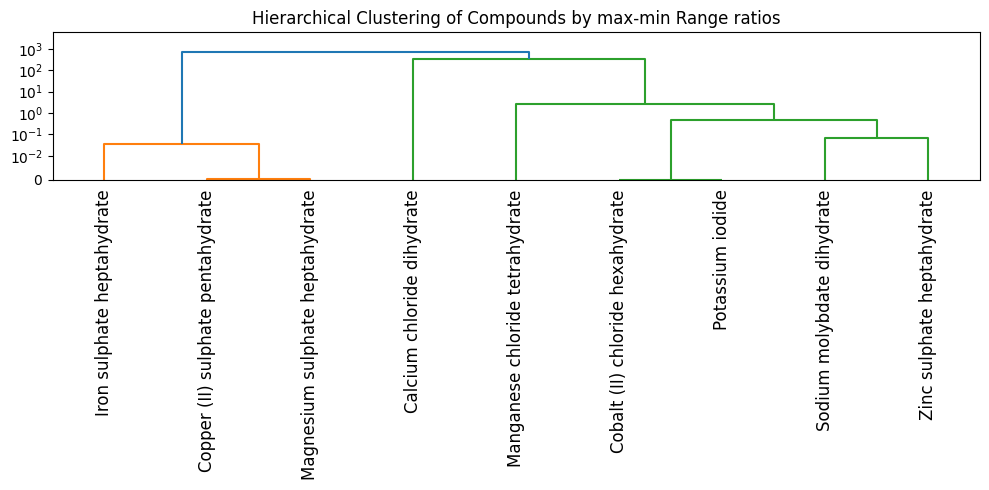

In [32]:
# select only numeric columns excluding compound ID columns
numeric_cols = ratio_df_e_reduced.drop(columns=['Compound_1', 'Compound_2']).select_dtypes(include='number').columns

# create new dataframe with range values
range_df_e = pd.DataFrame({
    'Compound_1': ratio_df_e_reduced['Compound_1'],
    'Compound_2': ratio_df_e_reduced['Compound_2'],
    'range': ratio_df_e_reduced[numeric_cols].replace(0, np.nan).max(axis=1) - ratio_df_e_reduced[numeric_cols].replace(0, np.nan).min(axis=1)
})

# Create a square distance matrix
compounds = pd.unique(range_df_e[['Compound_1', 'Compound_2']].values.ravel())
distance_matrix = pd.DataFrame(0, index=compounds, columns=compounds, dtype=float)

# Fill in distances symmetrically
for _, row in range_df_e.iterrows():
    c1, c2, dist = row['Compound_1'], row['Compound_2'], row['range']
    distance_matrix.loc[c1, c2] = dist
    distance_matrix.loc[c2, c1] = dist

# Ensure zero diagonal
np.fill_diagonal(distance_matrix.values, 0)

if distance_matrix.isnull().any().any():
    raise ValueError("Distance matrix contains NaNs — some compound pairs are missing.")

# Convert square matrix to condensed distance matrix
condensed_dist = squareform(distance_matrix.values)

# Perform hierarchical clustering
Z = linkage(condensed_dist, method='average')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=distance_matrix.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering of Compounds by max-min Range ratios")
plt.yscale('symlog', linthresh=0.01)
plt.ylim(0, distance_matrix.values.max() * 1.2)
plt.tight_layout()
plt.show()


Vitamin hierarchical tree

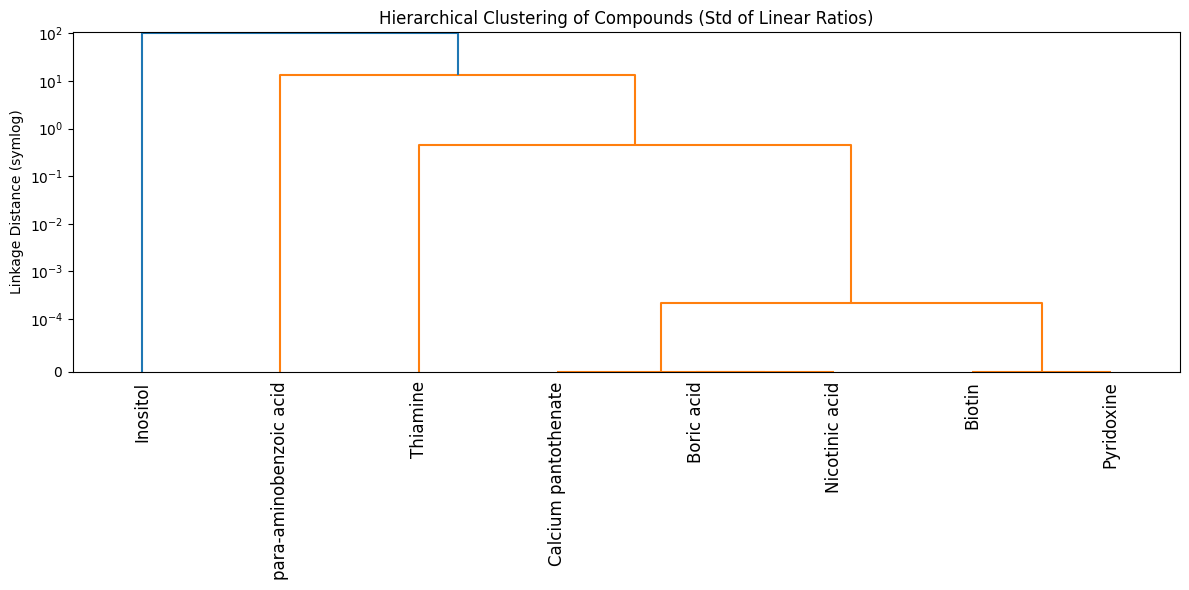

In [33]:
df_v = yar_df_vitamin.copy()
sample_cols = df_v.columns.difference(['Compound', 'Annotate'])

ratios = []


# all unique compound pairs
compound_pairs = list(itertools.combinations(df_v['Compound'], 2))

# map for quick lookup
compound_map = df_v.set_index('Compound')[sample_cols]

# loop through pairs
for c1, c2 in compound_pairs:
    vals1 = compound_map.loc[c1]
    vals2 = compound_map.loc[c2]

    # per-column mask
    valid_mask = (vals1>0) & (vals2 >0)
    ratio = vals1/vals2 

    #only keeps valid entries
    ratio_filtered = ratio.where(valid_mask)

    # store as a row with all per-column ratios
    row = {
        'Compound_1': c1,
        'Compound_2': c2,
        **ratio_filtered.to_dict()
    }
    ratios.append(row)

# create a dataframe
ratio_df_v = pd.DataFrame(ratios)

# drop these as they are simply repeats (this study varies carbon and nitrogen source which will be constant for our purposes)
# 1_YAR also removed
ratio_df_v_reduced = ratio_df_v.drop(columns=['1_YAR','2b_YAR', '2c_YAR', '2d_YAR', '3c_YAR'])

# Step 1: Compute SD per row
sample_cols = ratio_df_v_reduced.columns.difference(['Compound_1', 'Compound_2'])
ratio_df_v_reduced['Std_Ratio'] = ratio_df_v_reduced[sample_cols].replace(0, np.nan).std(axis=1, skipna=True) # added replace 0 for correct std calc

# Step 2: Create list of all unique compounds
compounds = pd.unique(ratio_df_v_reduced[['Compound_1', 'Compound_2']].values.ravel())

# Step 3: Initialize empty distance matrix
distance_matrix = pd.DataFrame(np.nan, index=compounds, columns=compounds)

# Step 4: Fill matrix with std values (symmetric)
for _, row in ratio_df_v_reduced.iterrows():
    c1, c2, std = row['Compound_1'], row['Compound_2'], row['Std_Ratio']
    distance_matrix.loc[c1, c2] = std
    distance_matrix.loc[c2, c1] = std

# Step 5: Set diagonal to 0
np.fill_diagonal(distance_matrix.values, 0)

# Step 6: Check for missing values
if distance_matrix.isnull().any().any():
    raise ValueError("Distance matrix contains NaNs — some compound pairs are missing.")

# Step 7: Run hierarchical clustering
condensed_dist = squareform(distance_matrix.values)
Z = linkage(condensed_dist, method='average')

# Step 8: Plot dendrogram
plt.figure(figsize=(12, 6))
dendrogram(Z, labels=distance_matrix.index.tolist(), leaf_rotation=90)
plt.yscale('symlog', linthresh=.0001)
plt.ylabel("Linkage Distance (symlog)")
plt.title("Hierarchical Clustering of Compounds (Std of Linear Ratios)")
plt.tight_layout()
plt.show()


In [34]:
# Get compound names
compounds = list(distance_matrix.index)

# Number of original observations
n = len(compounds)

# This will store merge history
merge_history = []

# Track cluster membership (compound names or merged groups)
clusters = {i: [compounds[i]] for i in range(n)}

# Loop over linkage matrix Z
for step, (idx1, idx2, dist, sample_count) in enumerate(Z):
    idx1, idx2 = int(idx1), int(idx2)
    
    # Get the clusters being merged
    members1 = clusters[idx1]
    members2 = clusters[idx2]

    # Merge the two clusters
    new_cluster = members1 + members2
    clusters[n + step] = new_cluster

    # Save merge info
    merge_history.append({
        'Step': step + 1,
        'Cluster_ID': n + step,
        'Merged_Cluster_1': members1,
        'Merged_Cluster_2': members2,
        'Linkage_Distance': dist,
        'Num_Compounds': len(new_cluster),
    })

# Convert to dataframe for easier viewing
merge_df = pd.DataFrame(merge_history)

# Display the merge table sorted by step (or by distance, if you prefer)
merge_df_sorted = merge_df.sort_values('Linkage_Distance', ascending=True)

# Print the table or write to CSV
print(merge_df_sorted.to_string(index=False))
# merge_df_sorted.to_csv("compound_merge_steps.csv", index=False)


 Step  Cluster_ID                                   Merged_Cluster_1                                                                                         Merged_Cluster_2  Linkage_Distance  Num_Compounds
    1           8                                       [Boric acid]                                                                                         [Nicotinic acid]      0.000000e+00              2
    2           9                             [Calcium pantothenate]                                                                             [Boric acid, Nicotinic acid]      0.000000e+00              3
    3          10                                           [Biotin]                                                                                             [Pyridoxine]      1.097135e-17              2
    4          11 [Calcium pantothenate, Boric acid, Nicotinic acid]                                                                                     [Biotin, Pyridoxine

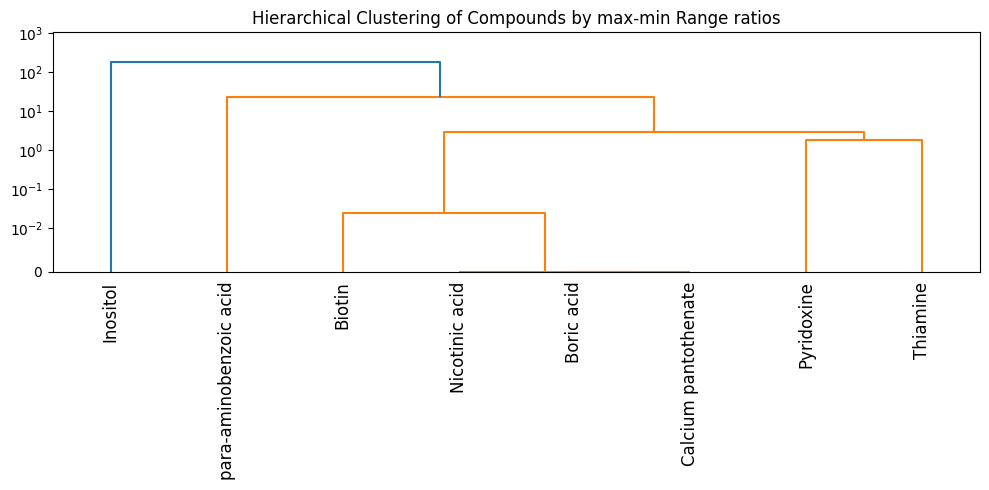

In [35]:
# select only numeric columns excluding compound ID columns
numeric_cols = ratio_df_v_reduced.drop(columns=['Compound_1', 'Compound_2']).select_dtypes(include='number').columns

# create new dataframe with range values
range_df_v = pd.DataFrame({
    'Compound_1': ratio_df_v_reduced['Compound_1'],
    'Compound_2': ratio_df_v_reduced['Compound_2'],
    'range': ratio_df_v_reduced[numeric_cols].replace(0, np.nan).max(axis=1) - ratio_df_v_reduced[numeric_cols].replace(0, np.nan).min(axis=1)
})

# Create a square distance matrix
compounds = pd.unique(range_df_v[['Compound_1', 'Compound_2']].values.ravel())
distance_matrix = pd.DataFrame(0, index=compounds, columns=compounds, dtype=float)

# Fill in distances symmetrically
for _, row in range_df_v.iterrows():
    c1, c2, dist = row['Compound_1'], row['Compound_2'], row['range']
    distance_matrix.loc[c1, c2] = dist
    distance_matrix.loc[c2, c1] = dist

# Ensure zero diagonal
np.fill_diagonal(distance_matrix.values, 0)

if distance_matrix.isnull().any().any():
    raise ValueError("Distance matrix contains NaNs — some compound pairs are missing.")

# Convert square matrix to condensed distance matrix
condensed_dist = squareform(distance_matrix.values)

# Perform hierarchical clustering
Z = linkage(condensed_dist, method='average')

# Plot dendrogram
plt.figure(figsize=(10, 5))
dendrogram(Z, labels=distance_matrix.index.tolist(), leaf_rotation=90)
plt.title("Hierarchical Clustering of Compounds by max-min Range ratios")
plt.yscale('symlog', linthresh=0.01)
plt.ylim(0, distance_matrix.values.max() * 1.2)
plt.tight_layout()
plt.show()

In [36]:
df_v_reduced = df_v.drop(columns=['1_YAR','2b_YAR', '2c_YAR', '2d_YAR', '3c_YAR']) # this is to remove the same experiments identified as redundant in above sections

df_v_reduced_nan = df_v_reduced.replace(0, np.nan) # replace 0 with Nans so correct min can be extracted

#selects numeric columns only
numeric_cols = df_v_reduced_nan.select_dtypes(include=[np.number]).columns


# Compute min and max for each compound, excluding NaNs
min_values = df_v_reduced_nan[numeric_cols].min(axis=1, skipna=True)
max_values = df_v_reduced_nan[numeric_cols].max(axis=1, skipna=True)
median_values = df_v_reduced_nan[numeric_cols].median(axis=1, skipna = True)
mean_values = df_v_reduced_nan[numeric_cols].mean(axis=1, skipna = True)

# Create a new dataframe with Compound, Min, and Max
df_v_min_max = pd.DataFrame({
    'Compound': df_v_reduced_nan['Compound'],
    'Min': min_values,
    'Max': max_values,
    'Median': median_values,
    'Mean': mean_values
})


In [51]:
print(df_v_min_max)

                  Compound           Min           Max        Median  \
5                   Biotin  3.274528e-08  3.069870e-07  1.023290e-07   
6               Boric acid  8.085382e-06  3.234153e-05  1.617076e-05   
8     Calcium pantothenate  2.280710e-06  6.842129e-06  4.561420e-06   
23                Inositol  1.110124e-08  2.081480e-04  6.938277e-05   
36          Nicotinic acid  4.061408e-06  1.218423e-05  8.122817e-06   
43              Pyridoxine  2.955432e-06  8.866296e-06  5.910864e-06   
52                Thiamine  2.964720e-07  4.986536e-06  1.662179e-06   
61  para-aminobenzoic acid  2.187546e-07  1.458364e-06  7.291819e-07   

            Mean  
5   1.358929e-07  
6   1.886589e-05  
8   4.561420e-06  
23  8.326657e-05  
36  8.122817e-06  
43  5.910864e-06  
52  2.172498e-06  
61  8.021000e-07  


In [ ]:
import numpy as np
import pandas as pd

class ClusterScaler:
    def __init__(self, df, cluster_compounds):
        """
        Args:
            df (pd.DataFrame): Must contain 'Compound', 'Min', 'Max', and 'Median' columns
            cluster_compounds (list of str): List of compounds to include in this cluster
        """
        self.df = df.set_index("Compound")
        self.compounds = cluster_compounds

        # Pull stats
        self.medians = self.df.loc[self.compounds, "Median"].to_dict()
        # use expaned bounds if available, otherwise use original min/max
        if 'Expanded_Min' in self.df.columns and 'Expanded_Max' in self.df.columns:
            self.mins = self.df.loc[self.compounds, "Expanded_Min"].to_dict()
            self.maxs = self.df.loc[self.compounds, "Expanded_Max"].to_dict()
        else:
            self.mins = self.df.loc[self.compounds, "Min"].to_dict()
            self.maxs = self.df.loc[self.compounds, "Max"].to_dict()

        # Log10 of medians
        self.log10_medians = {k: np.log10(v) for k, v in self.medians.items()}
        self.mean_log10 = np.mean(list(self.log10_medians.values()))

        # Offsets c_i
        self.offsets = {k: v - self.mean_log10 for k, v in self.log10_medians.items()}

    def log_concentration_from_alpha(self, alpha):
        return {compound: alpha + offset for compound, offset in self.offsets.items()}

    def concentration_from_alpha(self, alpha):
        return {compound: 10**(alpha + offset) for compound, offset in self.offsets.items()}

    def solve_alpha_for_target(self, compound, target_concentration):
        if compound not in self.offsets:
            raise ValueError(f"Compound '{compound}' not in this cluster.")
        return np.log10(target_concentration) - self.offsets[compound]

    def get_alpha_bounds(self):
        alpha_mins = []
        alpha_maxs = []

        for compound in self.compounds:
            c_i = self.offsets[compound]
            min_val = self.mins[compound]
            max_val = self.maxs[compound]
            alpha_min_i = np.log10(min_val) - c_i
            alpha_max_i = np.log10(max_val) - c_i
            alpha_mins.append(alpha_min_i)
            alpha_maxs.append(alpha_max_i)

        alpha_min = min(alpha_mins)
        alpha_max = max(alpha_maxs)

        if alpha_min > alpha_max:
            raise ValueError("No valid alpha range — bounds conflict between compounds.")

        return alpha_min, alpha_max


In [77]:
# Pick cluster manually
cluster = ["Pyridoxine", "Thiamine"]
scaler = ClusterScaler(df_v_min_max, cluster)

# Get bounds
alpha_bounds0 = scaler.get_alpha_bounds()
print(f"Alpha bounds for pyri, thiam: {alpha_bounds0}")

cluster = ["Nicotinic acid", "Boric acid", "Calcium pantothenate", "Biotin"]
scaler1 = ClusterScaler(df_v_min_max, cluster)
alpha_bounds1 = scaler1.get_alpha_bounds()
print(f"Alpha bounds for nico, boric, cal panto, biot: {alpha_bounds1}")
print(scaler1.concentration_from_alpha(-5.5
                                       ))

Alpha bounds for pyri, thiam: (np.float64(-6.252529718838498), np.float64(-5.026714388254678))
Alpha bounds for nico, boric, cal panto, biot: (np.float64(-6.047966029458532), np.float64(-5.075994753058776))
{'Nicotinic acid': np.float64(9.179577155072608e-06), 'Boric acid': np.float64(1.8274543071814157e-05), 'Calcium pantothenate': np.float64(5.154849899926959e-06), 'Biotin': np.float64(1.1564178129845157e-07)}


In [71]:
# Generate concentrations at some alpha
print(scaler1.concentration_from_alpha(-4))

# Anchor to Nicotinic acid = 8.122817e-6
alpha_target = scaler.solve_alpha_for_target("Thiamine", 2.965)
print(f"Alpha for exact match: {alpha_target:.4f}")

{'Nicotinic acid': np.float64(0.00029028371767278113), 'Boric acid': np.float64(0.0005778917930578275), 'Calcium pantothenate': np.float64(0.00016301066680060228), 'Biotin': np.float64(3.6569142158217084e-06)}
Alpha for exact match: 0.7475


In [76]:
print(df_v_min_max)

                  Compound           Min           Max        Median  \
5                   Biotin  3.274528e-08  3.069870e-07  1.023290e-07   
6               Boric acid  8.085382e-06  3.234153e-05  1.617076e-05   
8     Calcium pantothenate  2.280710e-06  6.842129e-06  4.561420e-06   
23                Inositol  1.110124e-08  2.081480e-04  6.938277e-05   
36          Nicotinic acid  4.061408e-06  1.218423e-05  8.122817e-06   
43              Pyridoxine  2.955432e-06  8.866296e-06  5.910864e-06   
52                Thiamine  2.964720e-07  4.986536e-06  1.662179e-06   
61  para-aminobenzoic acid  2.187546e-07  1.458364e-06  7.291819e-07   

            Mean  
5   1.358929e-07  
6   1.886589e-05  
8   4.561420e-06  
23  8.326657e-05  
36  8.122817e-06  
43  5.910864e-06  
52  2.172498e-06  
61  8.021000e-07  


In [72]:
print(df_v_reduced)

                  Compound Annotate        2a_YAR        3a_YAR        3b_YAR  \
5                   Biotin  Vitamin  1.023290e-07  3.274528e-08  3.274528e-08   
6               Boric acid  Vitamin  1.617076e-05  8.085382e-06  0.000000e+00   
8     Calcium pantothenate  Vitamin  2.280710e-06  0.000000e+00  0.000000e+00   
23                Inositol  Vitamin  6.938277e-05  2.497780e-08  1.110124e-08   
36          Nicotinic acid  Vitamin  4.061408e-06  0.000000e+00  0.000000e+00   
43              Pyridoxine  Vitamin  2.955432e-06  0.000000e+00  0.000000e+00   
52                Thiamine  Vitamin  1.662179e-06  5.929440e-07  2.964720e-07   
61  para-aminobenzoic acid  Vitamin  7.291819e-07  0.000000e+00  0.000000e+00   

           4_YAR         5_YAR  
5   2.046580e-07  3.069870e-07  
6   3.234153e-05  0.000000e+00  
8   4.561420e-06  6.842129e-06  
23  1.387660e-04  2.081480e-04  
36  8.122817e-06  1.218423e-05  
43  5.910864e-06  8.866296e-06  
52  3.324358e-06  4.986536e-06  
61  1.

In [75]:
print(ratio_df_e_reduced)

                           Compound_1                         Compound_2  \
0          Calcium chloride dihydrate   Cobalt (II) chloride hexahydrate   
1          Calcium chloride dihydrate  Copper (II) sulphate pentahydrate   
2          Calcium chloride dihydrate         Iron sulphate heptahydrate   
3          Calcium chloride dihydrate    Magnesium sulphate heptahydrate   
4          Calcium chloride dihydrate    Manganese chloride tetrahydrate   
5          Calcium chloride dihydrate                   Potassium iodide   
6          Calcium chloride dihydrate         Sodium molybdate dihydrate   
7          Calcium chloride dihydrate         Zinc sulphate heptahydrate   
8    Cobalt (II) chloride hexahydrate  Copper (II) sulphate pentahydrate   
9    Cobalt (II) chloride hexahydrate         Iron sulphate heptahydrate   
10   Cobalt (II) chloride hexahydrate    Magnesium sulphate heptahydrate   
11   Cobalt (II) chloride hexahydrate    Manganese chloride tetrahydrate   
12   Cobalt 